# Mutithreading
1. By default the code you write is single threaded in python
2. Multithreading means you can execute multiple threads simultaneously

In [1]:
import time
# Add a time delay of 2 seconds
time.sleep(2)
print("Hello")

Hello


In [2]:
%%time
time.sleep(2)
print("Hello")
time.sleep(1)
print("World")

Hello
World
CPU times: total: 0 ns
Wall time: 3 s


# Single threaded function exeution

In [4]:
def simple_interest(p, n, r):
    print("Simple Interest calulation started")
    time.sleep(2)
    i = (p * n * r) / 100
    a = p + i
    print(f"Simple Interest : {i:.2f} INR")
    print(f"Amount : {a:.2f} INR")
    print("Simple Interst function complete")

In [5]:
%%time
simple_interest(p=50_000, n=3, r=6.5)

Simple Interest calulation started
Simple Interest : 9750.00 INR
Amount : 59750.00 INR
Simple Interst function complete
CPU times: total: 0 ns
Wall time: 2 s


In [6]:
import math
def hypotenuse(a, b):
    print("Hypotenuse function started")
    time.sleep(3)
    c = math.sqrt(a**2 + b**2)
    print(f"Hypotenuse of {a} and {b} in {c:.4f}")
    print("Hyptenuse function complete")

In [7]:
%%time
hypotenuse(3, 4)

Hypotenuse function started
Hypotenuse of 3 and 4 in 5.0000
Hyptenuse function complete
CPU times: total: 0 ns
Wall time: 3 s


In [8]:
%%time
simple_interest(p=20000, n=5, r=7.1) # 2 sec
hypotenuse(5, 6) # 3 sec

Simple Interest calulation started
Simple Interest : 7100.00 INR
Amount : 27100.00 INR
Simple Interst function complete
Hypotenuse function started
Hypotenuse of 5 and 6 in 7.8102
Hyptenuse function complete
CPU times: total: 0 ns
Wall time: 5 s


# Mulitthreading execute both functions simulatneously

In [12]:
%%time
from threading import Thread

# Create the threads
th1 = Thread(target = simple_interest, args=(50000, 5, 6.5))
th2 = Thread(target = hypotenuse, args=(12, 13))

# Start all the threads
th1.start()
th2.start()

# Wait for all threads to finish
th1.join()
th2.join()

Simple Interest calulation started
Hypotenuse function started
Simple Interest : 16250.00 INR
Amount : 66250.00 INR
Simple Interst function complete
Hypotenuse of 12 and 13 in 17.6918
Hyptenuse function complete
CPU times: total: 31.2 ms
Wall time: 3.05 s


In [17]:
def square(n):
    print("Square calculation started")
    time.sleep(1)
    print(f"Square of {n} is {n**2}")

In [18]:
%%time
square(5)

Square calculation started
Square of 5 is 25
CPU times: total: 0 ns
Wall time: 1 s


In [19]:
%%time
simple_interest(p=23000, n=5, r=5.6)
hypotenuse(5, 7)
square(11)

Simple Interest calulation started


Simple Interest : 6440.00 INR
Amount : 29440.00 INR
Simple Interst function complete
Hypotenuse function started
Hypotenuse of 5 and 7 in 8.6023
Hyptenuse function complete
Square calculation started
Square of 11 is 121
CPU times: total: 0 ns
Wall time: 6.01 s


# Implement above using multithreading

In [20]:
%%time
from threading import Thread

# Create the threads
th1 = Thread(target=simple_interest, args=(20000, 4, 7.5))
th2 = Thread(target=hypotenuse, args=(7, 8))
th3 = Thread(target=square, args=(11,))

# Start all threads
th1.start()
th2.start()
th3.start()

# Wait for all threads to finish
th1.join()
th2.join()
th3.join()

Simple Interest calulation started
Hypotenuse function started
Square calculation started
Square of 11 is 121
Simple Interest : 6000.00 INR
Amount : 26000.00 INR
Simple Interst function complete
Hypotenuse of 7 and 8 in 10.6301
Hyptenuse function complete
CPU times: total: 15.6 ms
Wall time: 3.08 s


# Single function but want to calculate mulitple values

In [23]:
def square2(num):
    time.sleep(1)
    print(f"Square of {num} is {num ** 2}")

In [24]:
def square_list(a : list[int]):
    for i in a:
        square2(i)

In [25]:
%%time
a = [1, 2, 3, 11, 12, 13]
square_list(a)

Square of 1 is 1
Square of 2 is 4
Square of 3 is 9
Square of 11 is 121
Square of 12 is 144
Square of 13 is 169
CPU times: total: 15.6 ms
Wall time: 6.07 s


In [26]:
def square_multithreading(a: list[int]):
    # Intialize list of threads
    threads = []

    # Create threads and append to the list
    for i in a:
        th = Thread(target = square2, args=(i, ))
        th.start()
        threads.append(th)

    # Wait for all threads to finish
    for t in threads:
        t.join()

In [27]:
a

[1, 2, 3, 11, 12, 13]

In [29]:
%%time
square_multithreading(a)

Square of 1 is 1
Square of 2 is 4
Square of 3 is 9
Square of 11 is 121
Square of 12 is 144
Square of 13 is 169
CPU times: total: 15.6 ms
Wall time: 1.43 s


In [31]:
b = list(range(1, 101))
print(b)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100]


In [34]:
%%time
square_multithreading(b)

Square of 1 is 1
Square of 2 is 4
Square of 3 is 9
Square of 4 is 16
Square of 5 is 25
Square of 6 is 36
Square of 8 is 64
Square of 7 is 49
Square of 9 is 81
Square of 10 is 100
Square of 11 is 121
Square of 12 is 144
Square of 13 is 169
Square of 14 is 196
Square of 15 is 225
Square of 16 is 256
Square of 17 is 289
Square of 18 is 324
Square of 19 is 361
Square of 20 is 400
Square of 21 is 441
Square of 22 is 484
Square of 23 is 529
Square of 24 is 576
Square of 25 is 625
Square of 26 is 676
Square of 27 is 729
Square of 28 is 784
Square of 29 is 841
Square of 31 is 961
Square of 30 is 900
Square of 32 is 1024
Square of 33 is 1089
Square of 34 is 1156
Square of 35 is 1225
Square of 36 is 1296
Square of 38 is 1444
Square of 37 is 1369
Square of 39 is 1521
Square of 40 is 1600
Square of 41 is 1681
Square of 42 is 1764
Square of 43 is 1849
Square of 44 is 1936
Square of 45 is 2025
Square of 46 is 2116
Square of 59 is 3481
Square of 48 is 2304
Square of 49 is 2401
Square of 50 is 2500
Sq

# Downloading file from a url programatically

In [35]:
url1 = "https://raw.githubusercontent.com/utkarshg1/mlproject_regression/main/artifacts/data.csv"
print(url1)

https://raw.githubusercontent.com/utkarshg1/mlproject_regression/main/artifacts/data.csv


In [36]:
url1.split("/")

['https:',
 '',
 'raw.githubusercontent.com',
 'utkarshg1',
 'mlproject_regression',
 'main',
 'artifacts',
 'data.csv']

In [37]:
filename = url1.split("/")[-1]
filename

'data.csv'

In [38]:
import requests

def download_file(url: str):
    response = requests.get(url)
    response.raise_for_status()
    content = response.content
    filename = url.split("/")[-1]
    print(f"Downloading {filename} ...")
    # File io to save the content:
    with open(filename, "wb") as f:
        f.write(content)
    print(f"{filename} download complete")

In [39]:
url1

'https://raw.githubusercontent.com/utkarshg1/mlproject_regression/main/artifacts/data.csv'

In [41]:
%%time
download_file(url1)

data.csv download complete
CPU times: total: 1.06 s
Wall time: 1.49 s


In [42]:
urls = [
    "https://raw.githubusercontent.com/utkarshg1/mlproject_regression/main/artifacts/data.csv",
    "https://raw.githubusercontent.com/utkarshg1/mlproject_regression/main/artifacts/test.csv",
    "https://raw.githubusercontent.com/utkarshg1/mlproject_regression/main/artifacts/train.csv"
]
print(urls)

['https://raw.githubusercontent.com/utkarshg1/mlproject_regression/main/artifacts/data.csv', 'https://raw.githubusercontent.com/utkarshg1/mlproject_regression/main/artifacts/test.csv', 'https://raw.githubusercontent.com/utkarshg1/mlproject_regression/main/artifacts/train.csv']


In [43]:
%%time
for i in urls:
    download_file(i)

data.csv download complete
test.csv download complete
train.csv download complete
CPU times: total: 3.67 s
Wall time: 8.28 s


# Download with multithreading

In [44]:
def multithread_download(urls: list[str]):
    # Create a blank threads list
    threads = []

    # Create starts Append the threads into the list
    for i in urls:
        th = Thread(target = download_file, args=(i, ))
        th.start()
        threads.append(th)

    # Wait for all threads to finish
    for t in threads:
        t.join()

In [45]:
urls

['https://raw.githubusercontent.com/utkarshg1/mlproject_regression/main/artifacts/data.csv',
 'https://raw.githubusercontent.com/utkarshg1/mlproject_regression/main/artifacts/test.csv',
 'https://raw.githubusercontent.com/utkarshg1/mlproject_regression/main/artifacts/train.csv']

In [47]:
%%time
multithread_download(urls)

test.csv download complete
train.csv download complete
data.csv download complete
CPU times: total: 4.72 s
Wall time: 5 s


In [48]:
import pandas as pd
df = pd.read_csv("data.csv")
df.head()

,id,carat,cut,color,clarity,depth,table,x,y,z,price
0,0,1.52,Premium,F,VS2,62.2,58.0,7.27,7.33,4.55,13619
1,1,2.03,Very Good,J,SI2,62.0,58.0,8.06,8.12,5.05,13387
2,2,0.70,Ideal,G,VS1,61.2,57.0,5.69,5.73,3.50,2772
3,3,0.32,Ideal,G,VS1,61.6,56.0,4.38,4.41,2.71,666
4,4,1.70,Premium,G,VS2,62.6,59.0,7.65,7.61,4.77,14453


In [49]:
df.shape

(193573, 11)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193573 entries, 0 to 193572
Data columns (total 11 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       193573 non-null  int64  
 1   carat    193573 non-null  float64
 2   cut      193573 non-null  object 
 3   color    193573 non-null  object 
 4   clarity  193573 non-null  object 
 5   depth    193573 non-null  float64
 6   table    193573 non-null  float64
 7   x        193573 non-null  float64
 8   y        193573 non-null  float64
 9   z        193573 non-null  float64
 10  price    193573 non-null  int64  
dtypes: float64(6), int64(2), object(3)
memory usage: 16.2+ MB


In [53]:
a = (
    df.groupby(by = "color")
    .agg({"price": "mean"})
    .sort_values(by = "price", ascending=False)
    .round(2)
)
a

,price
color,
J,5756.31
I,5523.76
H,4776.55
G,4113.44
F,3652.35
E,2991.45
D,2976.19


<Axes: xlabel='color'>

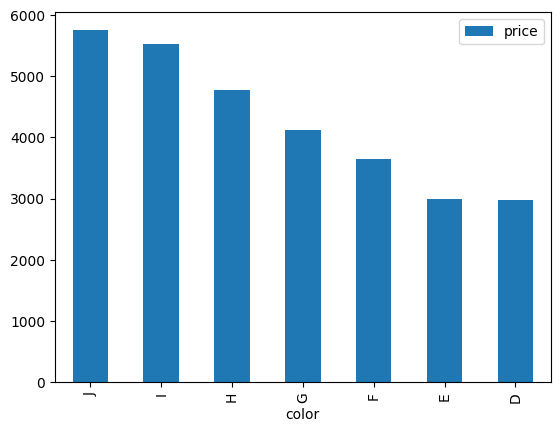

In [54]:
a.plot(kind="bar")

In [56]:
df.describe(include="number").describe().T

,count,mean,std,min,25%,50%,75%,max
id,8.0,103771.107021,69764.426774,0.000000,54008.142125,96786.000000,157277.2500,193573.0
carat,8.0,24197.510422,68438.032721,0.200000,0.447016,0.745344,1.6475,193573.0
depth,8.0,24243.150285,68419.594927,1.081704,59.000000,61.860287,64.7000,193573.0
table,8.0,24241.393315,68420.304839,1.918844,54.250000,57.113837,63.2500,193573.0
x,8.0,24200.798092,68436.704361,0.000000,3.802356,5.707656,7.2950,193573.0
y,8.0,24200.846553,68436.684784,0.000000,3.808083,5.720047,7.3850,193573.0
z,8.0,24202.372896,68436.068736,0.000000,2.347231,3.532123,10.8475,193573.0
price,8.0,28685.066194,66879.434789,326.000000,2038.500000,4001.764776,8760.5000,193573.0
